### 1. Import Libraries and Dataset

In [753]:
# Import Library
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [754]:
# Import Dataset
stock = 'BBCA.JK'
df = yf.download(stock, start='2021-01-01', end='2026-02-20')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24304\1949877501.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start='2021-01-01', end='2026-02-20')
[*********************100%***********************]  1 of 1 completed


In [755]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK
Date,,,,,
2021-01-04,6028.374023,6046.013743,5926.945638,5997.504515,47937000
2021-01-05,6253.281250,6253.281250,6041.604593,6050.424453,104831000
2021-01-06,6125.393555,6240.051749,6068.064457,6218.002097,89753500
2021-01-07,6143.033203,6218.002022,6094.523967,6173.902717,71360000
2021-01-08,6218.001953,6244.461536,6151.852996,6204.772162,75033500


### 2. Monte Carlo Simulation

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24304\2281225197.py:8: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  initial = int(df['Close'].iloc[-1])


Text(0.5, 1.0, "BBCA.JK's Monte Carlo Simulation")

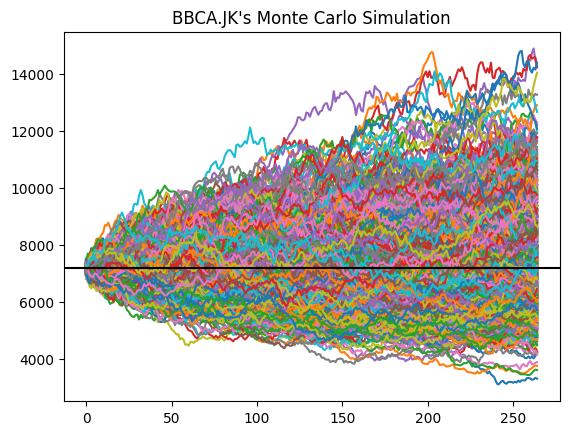

In [756]:
# log returns
returns = np.log(1 + df['Close'].pct_change())

# assigning mean and std dev
mu, std = returns.mean(), returns.std()

# initial
initial = int(df['Close'].iloc[-1])

# monte carlo loop 
sim_list = []
for i in range(1000):
    sim_rets = np.random.normal(mu, std, 265)
    sim_prices = initial * (sim_rets + 1).cumprod()
    sim_list.append(sim_prices)
    plt.plot(sim_prices)
plt.axhline(initial, c = 'k')
plt.title(f'{stock}\'s Monte Carlo Simulation')

### 3. General Trajectory Line

Text(0.5, 1.0, "BBCA.JK's Possible Trajectory Line")

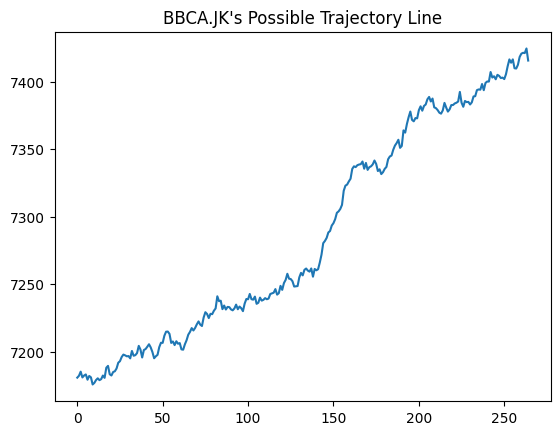

In [757]:
for list in (sim_list):
    sim_array = np.array(sim_list)
    mean_path = sim_array.mean(axis=0)
plt.plot(mean_path)
plt.title(f'{stock}\'s Possible Trajectory Line')

### 4. Finding Lowest Price Mean and Median

In [758]:
import statistics as stat

# Finding the lowest price possible
lowest_price_list = []
for list in (sim_list):
    lowest_price_list.append(min(list))
lowest_price_mean = stat.mean(lowest_price_list)
lowest_price_med = stat.median(lowest_price_list)

print(f'Lowest Price Mean: {lowest_price_mean}')
print(f'Lowest Price Median: {lowest_price_med}')

Lowest Price Mean: 6058.4241737815655
Lowest Price Median: 6152.301816841815


Text(0.5, 1.0, "BBCA.JK's Possible Lowest Price")

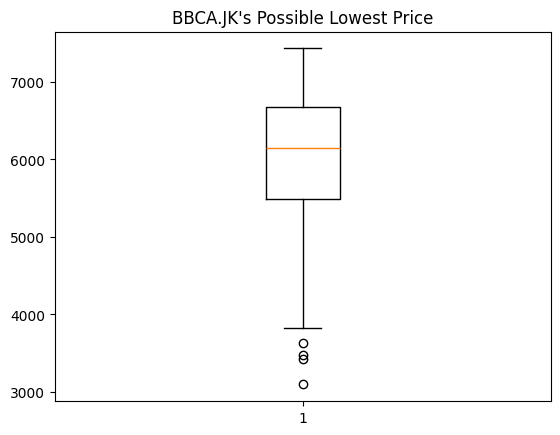

In [759]:
plt.boxplot(lowest_price_list)
plt.title(f'{stock}\'s Possible Lowest Price')